# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Alim Purnomo Aji Surya M.R
- **Email:** alimputra04@gmail.com
- **ID Dicoding:** mourizn


## Import Semua Packages/Library yang Digunakan

In [4]:
!pip install split-folders tensorflowjs
import splitfolders
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL

## Data Preparation

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hasibalmuzdadid/shoe-vs-sandal-vs-boot-dataset-15k-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'shoe-vs-sandal-vs-boot-dataset-15k-images' dataset.
Path to dataset files: /kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images


### Data Loading

In [5]:
# Gabungkan path untuk mengakses subfolder 'dataset'
data_dir = path # corrected from os.path.join(path, 'dataset')
print(os.listdir(data_dir)[0])
actual_dataset_path = os.path.join(data_dir, os.listdir(data_dir)[0])

for i in os.listdir(actual_dataset_path):
    path_to_cat = os.path.join(actual_dataset_path, i)
    if os.path.isdir(path_to_cat):
        print(f"{i} : {len(os.listdir(path_to_cat))} images")

Shoe vs Sandal vs Boot Dataset
Shoe : 5000 images
Sandal : 5000 images
Boot : 5000 images


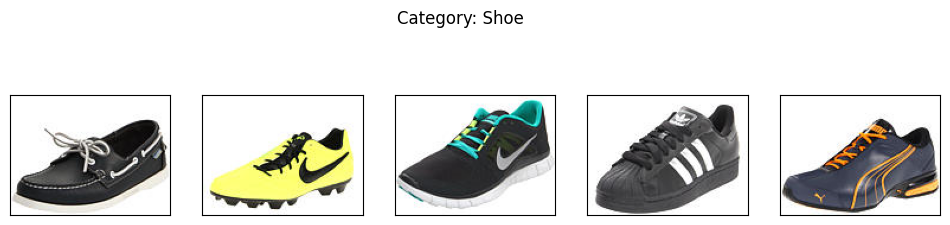

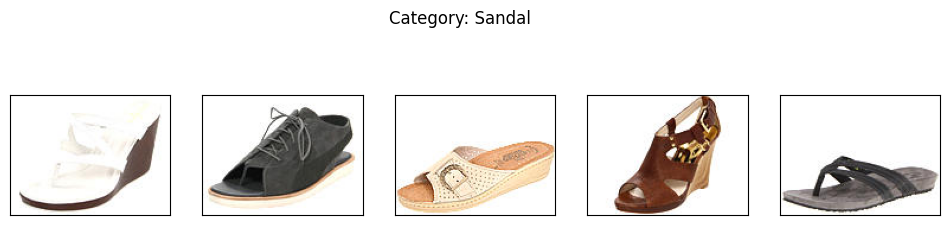

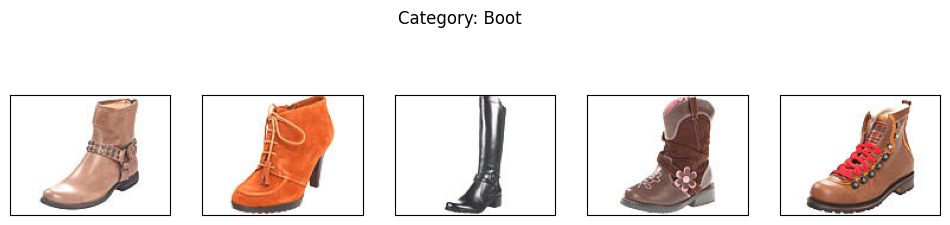

In [6]:
import os
import matplotlib.pyplot as plt

# Assuming data_dir is still the original path to versions/2
# We need to construct the path to the actual dataset directory
actual_dataset_path = os.path.join(data_dir, os.listdir(data_dir)[0])

# Now iterate through the actual categories (Shoe, Sandal, Boot)
for category in os.listdir(actual_dataset_path):
    category_path = os.path.join(actual_dataset_path, category)

    # Ensure it's a directory before proceeding (in case of hidden files etc.)
    if not os.path.isdir(category_path):
        continue

    # Ambil 5 file pertama dari setiap kategori
    # Here, images should be actual image files
    images = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))][:5]

    if not images: # Skip if no images found in category
        print(f"No images found in category: {category}")
        continue

    plt.figure(figsize=(12, 3))
    plt.suptitle(f"Category: {category}")
    for j in range(len(images)):
        img_path = os.path.join(category_path, images[j])
        plt.subplot(1, 5, j+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(plt.imread(img_path))
    plt.show()

### Data Preprocessing

#### Split Dataset

In [7]:


input_folder = actual_dataset_path
output_folder = "/content/footwear"

# Split with a ratio of (train, val, test)
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.7, .15, .15), group_prefix=None)


print("Contents of split folder:", os.listdir(output_folder))

Copying files: 15000 files [00:49, 305.32 files/s]

Contents of split folder: ['train', 'val', 'test']


In [8]:
for i in ['train', 'val', 'test']:
  for category in os.listdir(os.path.join(output_folder, i)):
    category_path = os.path.join(output_folder, i, category)
    count = len(os.listdir(category_path))
    print(f"Split: {i}, Category: {category}, Count: {count}")


Split: train, Category: Shoe, Count: 3500
Split: train, Category: Sandal, Count: 3500
Split: train, Category: Boot, Count: 3500
Split: val, Category: Shoe, Count: 750
Split: val, Category: Sandal, Count: 750
Split: val, Category: Boot, Count: 750
Split: test, Category: Shoe, Count: 750
Split: test, Category: Sandal, Count: 750
Split: test, Category: Boot, Count: 750


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = os.path.join(output_folder, 'train')
val_dir = os.path.join(output_folder, 'val')
test_dir = os.path.join(output_folder, 'test')

batch_size = 32
image_size = (150, 150)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 10500 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.


## Modelling

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D


In [11]:
train_generator.class_indices
num_classes = len(train_generator.class_indices)
print("Number of classes:", num_classes)

Number of classes: 3


In [12]:
# 1. Definisi Custom Callback
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.97 and logs.get('val_accuracy') > 0.97):
            print("\nAkurasi training > 97% dan validasi > 97%, hentikan training!")
            self.model.stop_training = True



accuracy_threshold = myCallback()

# 3. Arsitektur Model (input_shape disamakan dengan generator yaitu 150x150)
model = tf.keras.models.Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)), # Pastikan ukuran sama dengan generator
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 4
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classifier / Fully Connected Layer
    GlobalAveragePooling2D(), # Menggantikan Flatten agar model lebih ringan
    Dense(512, activation='relu'),
    Dropout(0.5), # Mencegah overfitting
    Dense(num_classes, activation='softmax') # Pastikan num_classes adalah 11 untuk dataset cuaca
])
model.summary()

# 2. Compile Model
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.optimizers.Adam(),
    metrics=['accuracy']
)

print("Memulai proses training...")
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator, # Menggunakan nama variabel yang benar
    verbose=1,
    callbacks=[accuracy_threshold]
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 523,459 (2.00 MB)

 Trainable params: 522,499 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)

Memulai proses training...
Epoch 1/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 93s 252ms/step - accuracy: 0.7116 - loss: 0.6681 - val_accuracy: 0.6453 - val_loss: 0.8165
Epoch 2/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 67s 205ms/step - accuracy: 0.8235 - loss: 0.4426 - val_accuracy: 0.4338 - val_loss: 1.3159
Epoch 3/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 66s 201ms/step - accuracy: 0.8575 - loss: 0.3630 - val_accuracy: 0.6418 - val_loss: 1.1062
Epoch 4/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 66s 201ms/step - accuracy: 0.8866 - loss: 0.3016 - val_accuracy: 0.8027 - val_loss: 0.5166
Epoch 5/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 66s 200ms/step - accuracy: 0.8968 - loss: 0.2683 - val_accuracy: 0.6436 - val_loss: 1.8503
Epoch 6/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 66s 199ms/step - accuracy: 0.9102 - loss: 0.2422 - val_accuracy: 0.7636 - val_loss: 1.1816
Epoch 7/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 65s 199ms/step - accuracy: 0.9165 - loss: 0.2283 - val_accuracy: 0.4751 - val_loss: 2.8242
Epoch 8/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 65s 199m

## Evaluasi dan Visualisasi

In [13]:
try:
    print("\n1. Mengevaluasi pada Validation Set...")
    val_loss, val_accuracy = model.evaluate(validation_generator, verbose=0)
    print(f"   Akurasi pada Validation Set : {val_accuracy * 100:.2f}%")

    print("\n2. Mengevaluasi pada Test Set...")
    test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
    print(f"   Akurasi pada Test Set       : {test_accuracy * 100:.2f}%")
except Exception as e:
    print(f"\nTerjadi error saat evaluasi: {e}")


1. Mengevaluasi pada Validation Set...
   Akurasi pada Validation Set : 97.24%

2. Mengevaluasi pada Test Set...
   Akurasi pada Test Set       : 97.29%


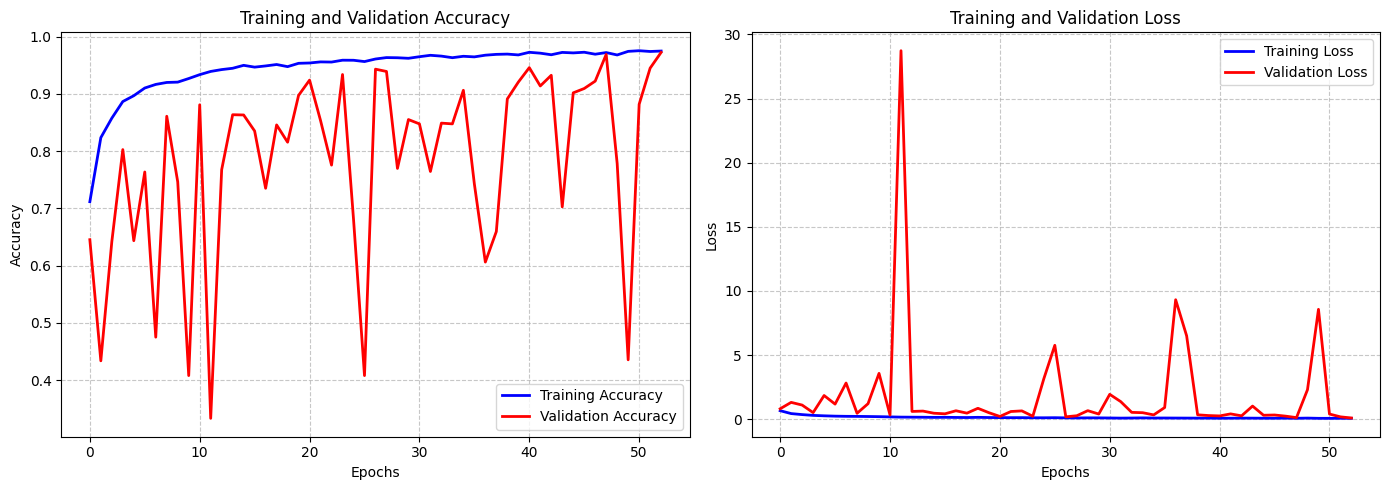

In [14]:
import matplotlib.pyplot as plt

# Mengambil data dari variabel history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Menentukan jumlah epoch yang berjalan
epochs_range = range(len(acc))

# Membuat figure untuk menampung plot
plt.figure(figsize=(14, 5))

# Plot 1: Akurasi Training vs Validasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red', linewidth=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Loss Training vs Validasi
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

## Konversi Model

In [22]:
import os
import shutil
import tensorflow as tf
import tensorflowjs as tfjs

# 1. Membuat direktori utama dan sub-direktori
base_dir = '/content/submission'
os.makedirs(os.path.join(base_dir, 'tfjs_model'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'tflite'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'saved_model'), exist_ok=True)

print("Memulai proses ekspor model ke dalam folder submission...\n")

# ==========================================
# 2. Simpan sebagai SavedModel
# ==========================================
saved_model_path = os.path.join(base_dir, 'saved_model')
# Perbaikan: Menggunakan model.export() untuk format SavedModel folder
model.export(saved_model_path)
print("[INFO] Model berhasil disimpan ke format SavedModel.")

# ==========================================
# 3. Konversi ke TF-Lite & Buat label.txt
# ==========================================
tflite_path = os.path.join(base_dir, 'tflite', 'model.tflite')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

class_names = sorted(train_generator.class_indices.keys())
label_path = os.path.join(base_dir, 'tflite', 'label.txt')
with open(label_path, 'w') as f:
    f.write('\n'.join(class_names))
print("[INFO] Model berhasil dikonversi ke TFLite beserta file label.txt.")

# ==========================================
# 4. Konversi ke TFJS
# ==========================================
tfjs_path = os.path.join(base_dir, 'tfjs_model')
tfjs.converters.save_keras_model(model, tfjs_path)
print("[INFO] Model berhasil dikonversi ke TFJS.")

# ==========================================
# 5. Membuat file requirements.txt
# ==========================================
requirements_path = os.path.join(base_dir, 'requirements.txt')
with open(requirements_path, 'w') as f:
    f.write("tensorflow\ntensorflowjs\npandas\nnumpy\nscikit-learn\nsplit-folders\n")
print("[INFO] File requirements.txt berhasil dibuat.")

print("\nStruktur folder submission berhasil dibentuk!")

Memulai proses ekspor model ke dalam folder submission...

Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134051352237008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134051352240080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134051352242000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134051352239696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134051352239504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134051352241040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134051352241616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134051352241808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134051352243536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1340513522

[INFO] Model berhasil dikonversi ke TFLite beserta file label.txt.
failed to lookup keras version from the file,
    this is likely a weight only file
[INFO] Model berhasil dikonversi ke TFJS.
[INFO] File requirements.txt berhasil dibuat.

Struktur folder submission berhasil dibentuk!


In [23]:
from google.colab import files

# Mengompres folder submission
shutil.make_archive('/content/submission_akhir', 'zip', '/content/submission')

print("Mengunduh file submission_akhir.zip ke komputer...")
files.download('/content/submission_akhir.zip')

Mengunduh file submission_akhir.zip ke komputer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference (Optional)

Saving 1_A7315560001105_20240109092611034_base.jpg to 1_A7315560001105_20240109092611034_base.jpg


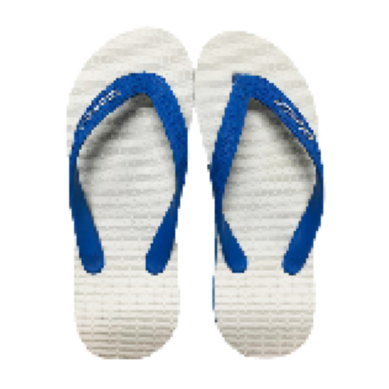

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
File: 1_A7315560001105_20240109092611034_base.jpg
Prediksi: Sandal (96.91%)


In [19]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Upload Gambar
uploaded = files.upload()

# Ambil daftar label dari generator
class_indices = train_generator.class_indices
labels = {v: k for k, v in class_indices.items()}

for fn in uploaded.keys():

  # 2. Preprocessing Gambar
  path = fn
  img = image.load_img(path, target_size=(150, 150))
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = x / 255.0 # Rescale sama seperti training

  # 3. Prediksi
  classes = model.predict(x, batch_size=10)
  predicted_class = labels[np.argmax(classes)]
  confidence = np.max(classes) * 100

  print(f"File: {fn}")
  print(f"Prediksi: {predicted_class} ({confidence:.2f}%)")